<a href="https://colab.research.google.com/github/acshon99/consumer-behavior/blob/main/Business_Question_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 2: Influence of Demographics on Spending

How do factors like *age*, *monthly_income*, and *city_tier* influence a consumer's average online and in-store spending (*avg_online_spend*, *avg_store_spend*)?

In [ ]:
import os
import kagglehub

# Download latest version to ensure 'path' is defined
path = kagglehub.dataset_download("sohaibdevv/consumer-shopping-behavior-and-preference-study-2026")
print("Path to dataset files:", path)

# List the contents of the downloaded directory to find the correct CSV file
print("Contents of the dataset directory:")
for root, dirs, files in os.walk(path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

# Construct the full path to the CSV file with the correct name
csv_file_path = os.path.join(path, 'Consumer_Shopping_Trends_2026 (6).csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_file_path)

print(f"DataFrame 'df' loaded with shape: {df.shape}")
print(df.head())

Using Colab cache for faster access to the 'consumer-shopping-behavior-and-preference-study-2026' dataset.
Path to dataset files: /kaggle/input/consumer-shopping-behavior-and-preference-study-2026
Contents of the dataset directory:
/kaggle/input/consumer-shopping-behavior-and-preference-study-2026/.nfs000000009c83bb690000003d
/kaggle/input/consumer-shopping-behavior-and-preference-study-2026/Consumer_Shopping_Trends_2026 (6).csv
DataFrame 'df' loaded with shape: (11789, 25)
   age  monthly_income  daily_internet_hours  smartphone_usage_years  \
0   56          221111                   6.5                      12   
1   69           96029                   8.2                      13   
2   46           19055                   6.4                       4   
3   32           53170                   6.4                      11   
4   60          244016                   6.0                       5   

   social_media_hours  online_payment_trust_score  tech_savvy_score  \
0                

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
# Grouping City Tier by Category and Calculating the Meam for Factors of Interest
city_tier_spending = df.groupby('city_tier', observed=False)[['avg_online_spend', 'avg_store_spend']].mean()
print(city_tier_spending)

           avg_online_spend  avg_store_spend
city_tier                                   
Tier 1         74520.516323     75149.958815
Tier 2         74907.779679     76012.244168
Tier 3         74244.910610     75835.050393


In [ ]:
# Re-loading the dataframe to ensure 'city_tier' column is correctly populated.
df = pd.read_csv(csv_file_path)

df['city_tier_category'] = df['city_tier']

print("Value counts for the new city_tier column after re-initialization:")
print(df['city_tier_category'].value_counts())

Value counts for the new city_tier column after re-initialization:
city_tier_category
Tier 1    3982
Tier 3    3949
Tier 2    3858
Name: count, dtype: int64


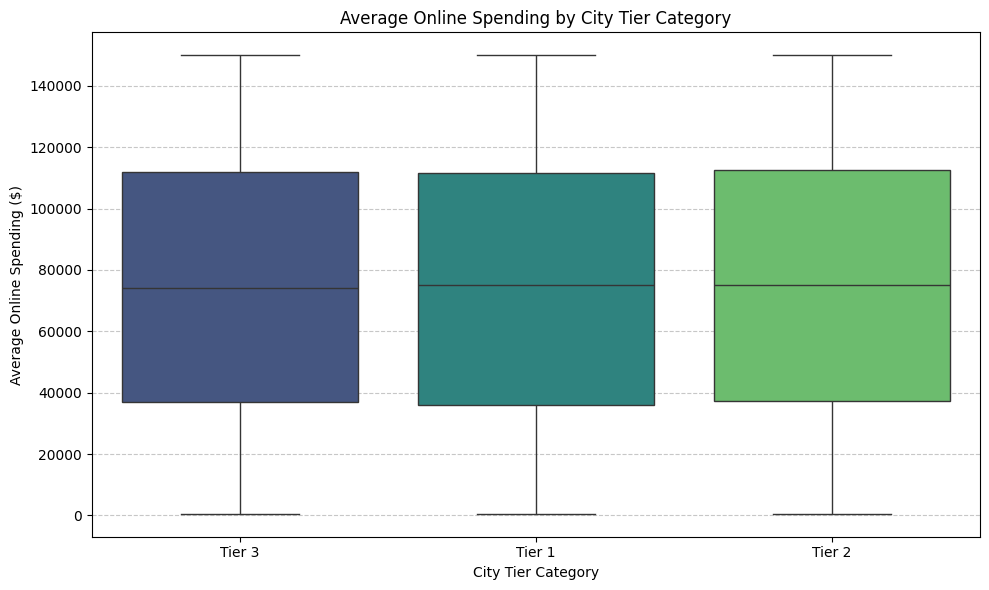

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot of avg_online_spend grouped by city_tier_category
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='city_tier_category', y='avg_online_spend', data=df, ax=ax, hue='city_tier_category', palette='viridis', legend=False)
ax.set_title('Average Online Spending by City Tier Category')
ax.set_xlabel('City Tier Category')
ax.set_ylabel('Average Online Spending ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

age_group
0-18     68752.931818
19-25    73954.025404
26-35    74615.345686
36-50    74235.388424
51+      75023.535181
Name: avg_online_spend, dtype: float64


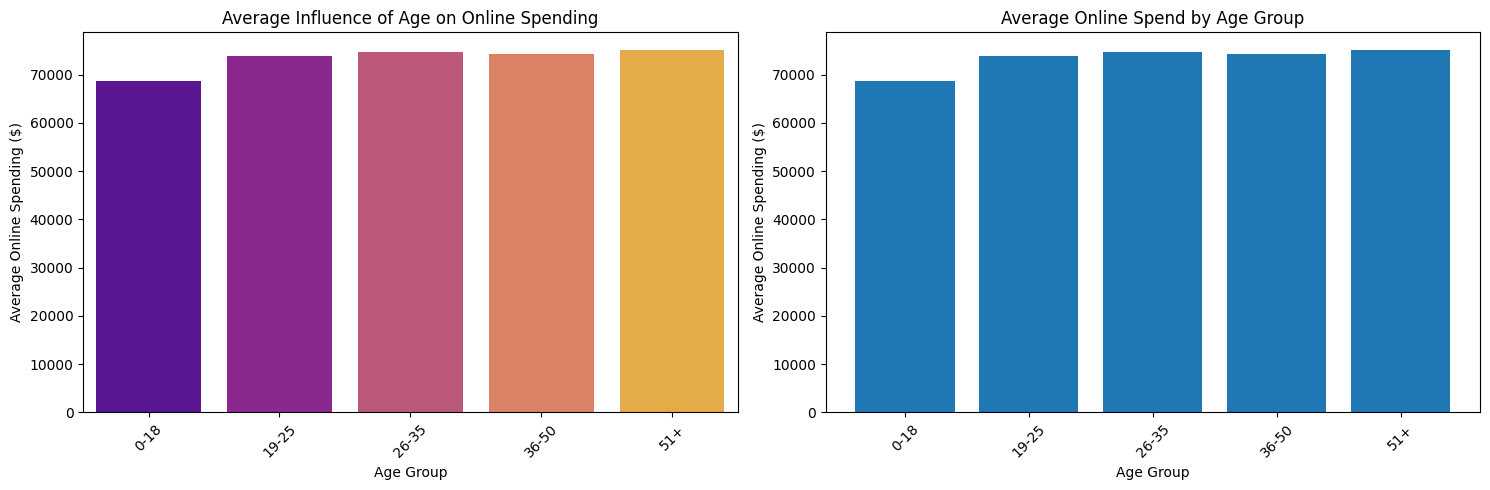

In [ ]:
# Categorizing age into bins and calculating the average and spending
age_bins = [0, 18, 25, 35, 50, 100]
age_labels = ['0-18', '19-25', '26-35', '36-50', '51+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Group by age group and calculate the mean spending (using avg_online_spend)
age_spending = df.groupby('age_group', observed=False)['avg_online_spend'].mean()
print(age_spending)

# Visualize the influence of age on spending
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Using seaborn barplot on the first axes
sns.barplot(x=age_spending.index, y=age_spending.values, ax=ax[0], hue=age_spending.index, palette = 'plasma', legend=False)
ax[0].set_xlabel('Age Group')
ax[0].set_ylabel('Average Online Spending ($)')
ax[0].set_title('Average Influence of Age on Online Spending')
ax[0].set_xticks(range(len(age_spending.index))) # Set tick locations
ax[0].set_xticklabels(age_spending.index, rotation=45)

# Plot 2: Using matplotlib bar plot on the second axes
ax[1].bar(age_spending.index, age_spending.values)
ax[1].set_xlabel('Age Group')
ax[1].set_ylabel('Average Online Spending ($)') # Corrected label
ax[1].set_title('Average Online Spend by Age Group') # Corrected title
ax[1].set_xticks(range(len(age_spending.index))) # Set tick locations
ax[1].set_xticklabels(age_spending.index, rotation=45)
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

monthly_income_category
Quintile 1 (lowest)     2358
Quintile 2              2358
Quintile 4              2358
Quintile 5 (Highest)    2358
Quintile 3              2357
Name: count, dtype: int64

Average Online Spending by Monthly Income Quintile:
 monthly_income_category
Quintile 1 (lowest)     72790.968193
Quintile 2              74781.502120
Quintile 3              76129.653797
Quintile 4              74467.477099
Quintile 5 (Highest)    74605.713316
Name: avg_online_spend, dtype: float64

Descriptive statistics for Monthly Income by Quintile:
                          count           mean           std       min  \
monthly_income_category                                                  
Quintile 1 (lowest)      2358.0   37420.910941  13106.007042   15005.0   
Quintile 2               2358.0   84626.733249  13874.942586   60784.0   
Quintile 3               2357.0  131649.911752  13328.560984  108558.0   
Quintile 4               2358.0  178214.977099  14064.191877  154322.0   
Qui

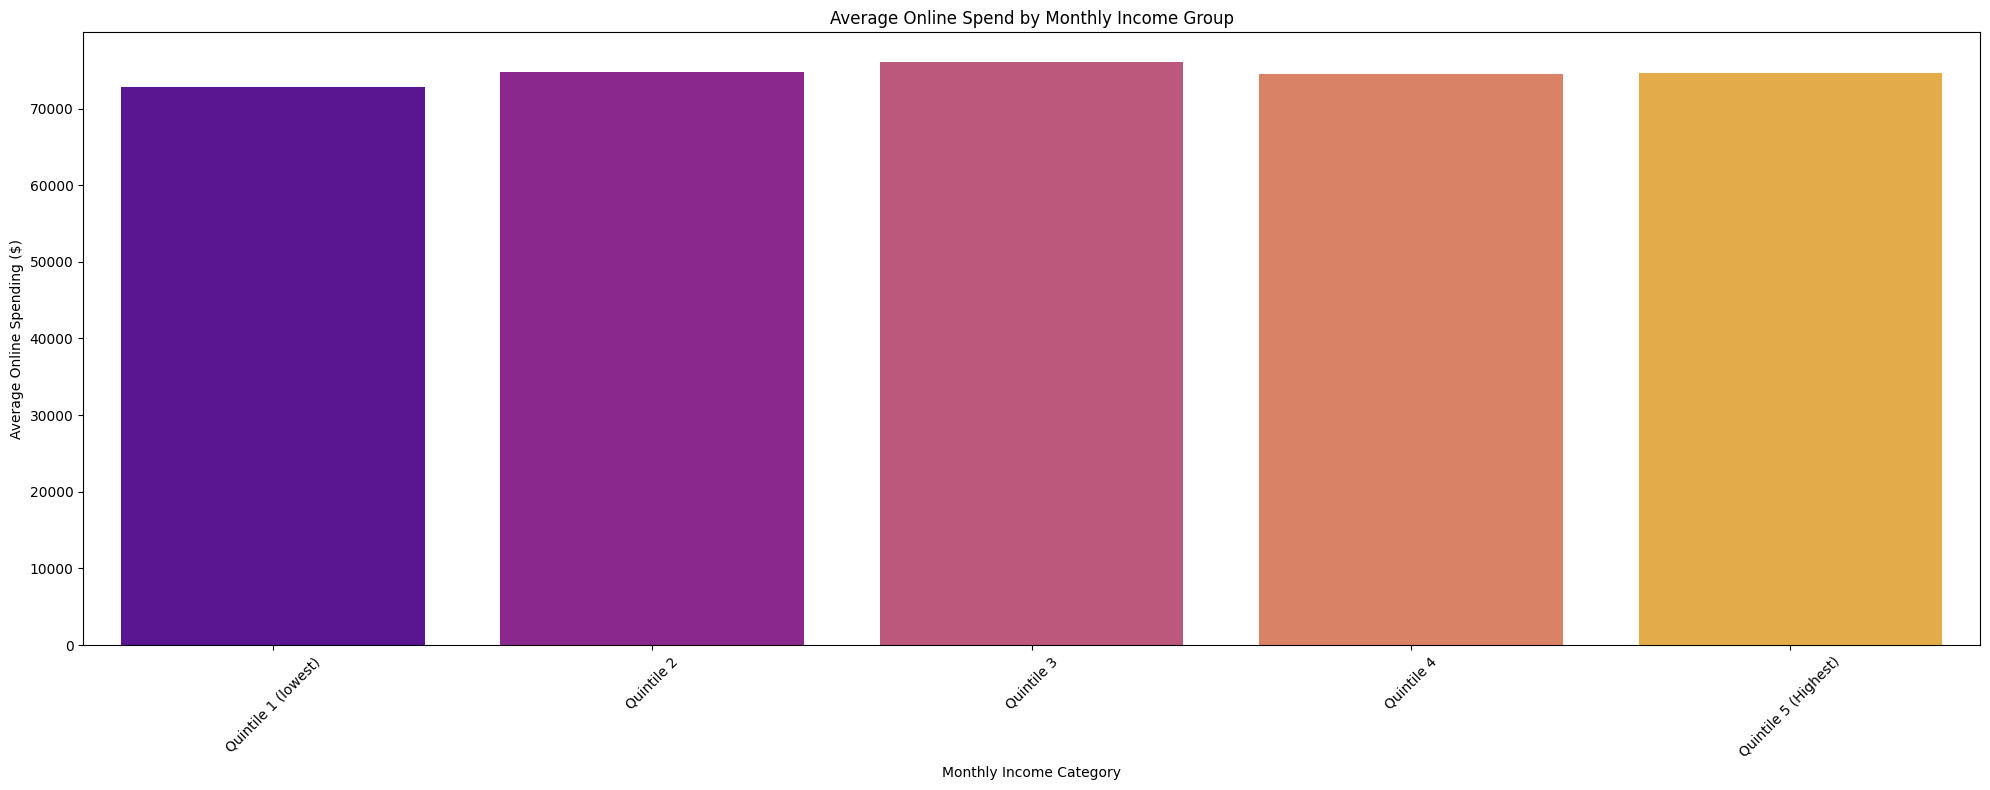

In [ ]:
# Influence of Monthly Income on Spending
df['monthly_income_category'] = pd.qcut(df['monthly_income'], q=5, labels=['Quintile 1 (lowest)', 'Quintile 2', 'Quintile 3', 'Quintile 4', 'Quintile 5 (Highest)'], duplicates='drop')
print(df['monthly_income_category'].value_counts())

# Grouping by income and calculating mean spending
income_spending = df.groupby('monthly_income_category', observed=False)['avg_online_spend'].mean()
print("\nAverage Online Spending by Monthly Income Quintile:\n", income_spending)

# Display descriptive statistics for monthly income within each quintile
print("\nDescriptive statistics for Monthly Income by Quintile:")
print(df.groupby('monthly_income_category', observed=False)['monthly_income'].describe())

# Visualizing the influence of monthly income on spending
fig, axes = plt.subplots(1, figsize=(20, 8))

# Plot 1
sns.barplot(x=income_spending.index, y=income_spending, ax=axes, hue=income_spending.index, palette = 'plasma', legend=False)
axes.set_xlabel('Monthly Income Category')
axes.set_ylabel('Average Online Spending ($)')
axes.set_title('Average Online Spend by Monthly Income Group')
axes.set_xticks(range(len(income_spending.index)))
axes.set_xticklabels(income_spending.index, rotation=45)
axes.tick_params(axis='x', labelbottom=True) # Ensure x-axis labels are visible if rotation causes issues

plt.tight_layout()
plt.show()

Average Spending by City Tier:
   city_tier_category  avg_online_spend
0             Tier 1      74520.516323
1             Tier 2      74907.779679
2             Tier 3      74244.910610


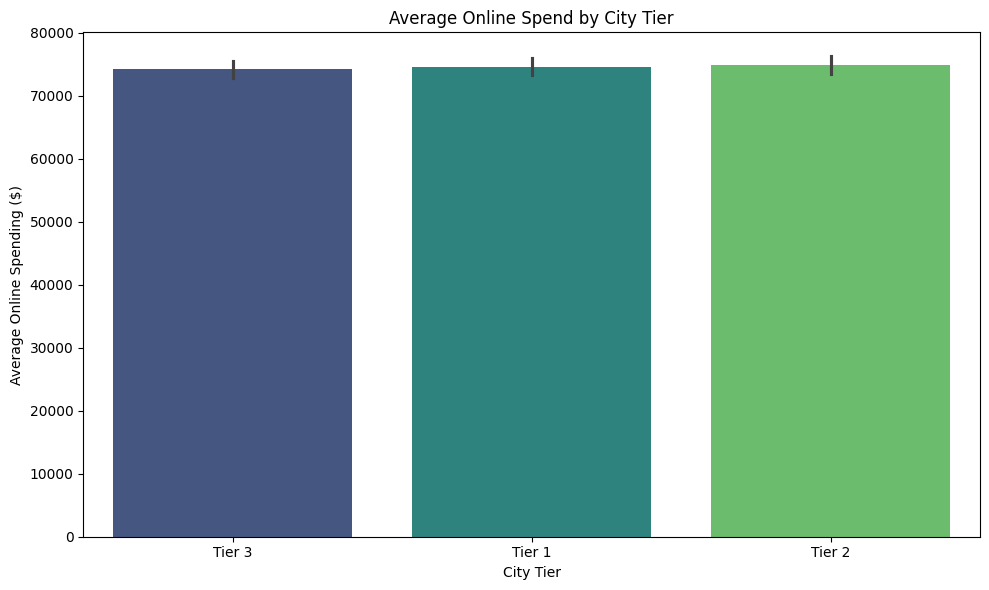

In [ ]:
# Influence of City Tier on Spending
city_tier_spending = df.groupby('city_tier_category', observed=False)['avg_online_spend'].mean().reset_index()
print("Average Spending by City Tier:\n", city_tier_spending)

# Visualizing the influence of city tier on spending
fig, axes = plt.subplots(1, figsize=(10, 6))
sns.barplot(x='city_tier_category', y='avg_online_spend', data=df, ax=axes, hue='city_tier_category', palette = 'viridis', legend=False)
axes.set_xlabel('City Tier')
axes.set_ylabel('Average Online Spending ($)')
axes.set_title('Average Online Spend by City Tier')

plt.tight_layout()
plt.show()

# Explanation:

# 1. Influence of Age on Online Spending

The analysis has categorized ages into five groups and has shown that the average online spending generally shows an increasing trend with age. The 51+ age group exhibited the highest average online spending, suggesting that older consuers tend to spend more online, with a peak in the 51+ age bracket.

# 2. Influence of Monthly Income on Spending

The monthly incoe was divided into 5 quintiles, with Quintile 1 being the lowest to Quintile 5 being the highest. Quintile 1 demonstrates to be the lowest income, with Quintile 5 showing to be the highest income.

There is an initial increase in average online spending from the lowest income quintile up to quintile 3. For the highest income quintiles (4 and 5), the aerage online spending appears to stabilize or decrease compared to quintile 3, This indicates that while higher income generally correlates with increased online spending up to a certain point, the absolute highest earners do not necessarily spend proportionally more online than the upper-middle income groups.

# 3. Influence of City Tier on Spending

The analysis shows a barplot that summarizes the average online and in-store spending across different city tiers. City tiers do not have a strong influence on how much consumers spend, either online or in-store, when considering average spending levels.

# 4. Variation by City Tier Category

The table displays the average values of factors of interest (*discount_sensitvity*, *return_frewuency*, *delivery_fee_sensivity*, *free_return_importance*) across different *city_tier* categories:
- **Consistent Trends**: The average scores scores for all four factors (*discount_sensitvity*, *return_frequency*, *delivery_fee_sensivitity*, *free_return_importance*) are remarkably consistent across Tier 1, Tier 2, and Tier 3 cities.
- **Minor Differences**: Any observed differences are very slight and likely not statistically significant. For example, *discount_sensitivity*, and *free_return_importance* are almost identical across the tiers.

The analysis indicates that the *city_tier* doesn't play a significant role in influencing consumers' sensivity to discounts, return frequency, delivery fees, or the importance they place on free returns. These factors appear to be driven by other individual or behavioral attributes rather than the type of city they reside in.
